In [3]:
import sys
print(sys.executable)

d:\Second heand price pridication\.venv\Scripts\python.exe


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('cardekho_dataset.csv')
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['selling_price'].describe()

count    1.541100e+04
mean     7.749711e+05
std      8.941284e+05
min      4.000000e+04
25%      3.850000e+05
50%      5.560000e+05
75%      8.250000e+05
max      3.950000e+07
Name: selling_price, dtype: float64

In [10]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

In [11]:
df=df.drop(['Unnamed: 0', 'car_name'],axis=1)

In [12]:
df.head()

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [13]:
df['brand'] = df['brand'].str.lower()

In [14]:
counts = df['brand'].value_counts()
luxiry = counts[counts < 10].index
df['brand'] = df['brand'].apply(lambda x: 'other' if x in luxiry else x)

In [15]:
df['brand'].value_counts()

brand
maruti           4992
hyundai          2982
honda            1485
mahindra         1011
toyota            793
ford              790
volkswagen        620
renault           536
bmw               439
tata              430
mercedes-benz     337
skoda             334
audi              192
datsun            170
jaguar             59
land rover         51
jeep               41
kia                32
porsche            21
volvo              20
mg                 19
mini               17
nissan             11
isuzu              10
lexus              10
other               9
Name: count, dtype: int64

In [16]:
df.columns

Index(['brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='object')

In [17]:
df['model'] = df['model'].str.lower()
df['model'].value_counts()

model
i20             906
swift dzire     890
swift           781
alto            778
city            757
               ... 
altroz            1
c                 1
ghost             1
quattroporte      1
gurkha            1
Name: count, Length: 120, dtype: int64

In [18]:
counts=df['model'].value_counts()
model=counts[counts<2].index
model

Index(['ghibli', 'aura', 'gtc4lusso', 'altroz', 'c', 'ghost', 'quattroporte',
       'gurkha'],
      dtype='object', name='model')

In [19]:
df['seller_type'] = df['seller_type'].replace({'Trustmark Dealer': 'Dealer'})
df['seller_type'].value_counts()

seller_type
Dealer        9712
Individual    5699
Name: count, dtype: int64

In [20]:
df['fuel_type'].value_counts()

fuel_type
Petrol      7643
Diesel      7419
CNG          301
LPG           44
Electric       4
Name: count, dtype: int64

In [21]:
df['transmission_type'].value_counts()

transmission_type
Manual       12225
Automatic     3186
Name: count, dtype: int64

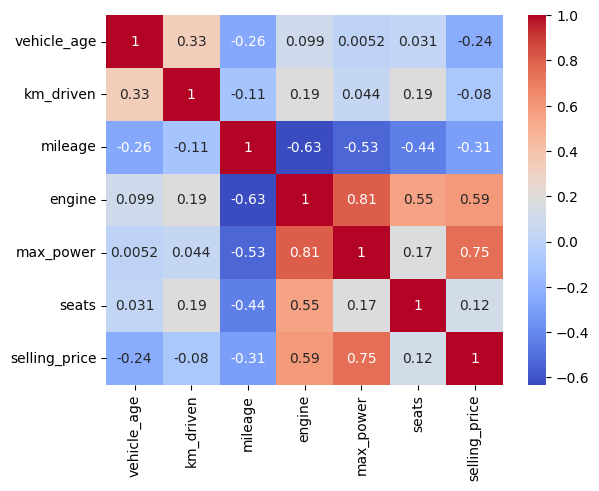

In [22]:
numeric_cols = df.select_dtypes(include='number')
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.show()

In [23]:
numeric_cols.corr()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
vehicle_age,1.000000,0.333891,-0.257394,0.098965,0.005208,0.030791,-0.241851
km_driven,0.333891,1.000000,-0.105239,0.192885,0.044421,0.192830,-0.080030
mileage,-0.257394,-0.105239,1.000000,-0.632987,-0.533128,-0.440280,-0.305549
engine,0.098965,0.192885,-0.632987,1.000000,0.807368,0.551236,0.585844
max_power,0.005208,0.044421,-0.533128,0.807368,1.000000,0.172257,0.750236
seats,0.030791,0.192830,-0.440280,0.551236,0.172257,1.000000,0.115033
selling_price,-0.241851,-0.080030,-0.305549,0.585844,0.750236,0.115033,1.000000


In [ ]:
# Avoid data leakage by encoding only using training set during modeling


ValueError: Lengths must match to compare

In [ ]:

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline

class FeatureEngineering(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Feature Engineering
        X['km_per_year'] = X['km_driven'] / (X['vehicle_age'] + 1)
        X['power_to_engine'] = X['max_power'] / (X['engine'] + 1)

        return X

counts = df['brand'].value_counts()
luxiry = counts[counts < 10].index
df['brand'] = df['brand'].apply(lambda x: 'other' if x in luxiry else x)

cat_low = ['brand', 'fuel_type', 'seller_type', 'transmission_type']
cat_high = ['model']
num_cols = [
    'vehicle_age', 'km_driven', 'mileage',
    'engine', 'max_power', 'seats',
    'km_per_year', 'power_to_engine'
]


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_low),
        ('target', TargetEncoder(), cat_high),
        ('num', 'passthrough', num_cols)
    ]
)

In [ ]:
df.head()

In [ ]:
print(df.dtypes)

In [ ]:
selling_price = np.log1p(df['selling_price'])
sns.histplot(selling_price)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score ,mean_absolute_error

x=df.drop('selling_price',axis=1)
y=np.log1p(df['selling_price'])

x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.2)

In [ ]:
sns.histplot(y)
plt.show()

In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)


In [ ]:
y_pred=model.predict(x_test)

In [ ]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [ ]:
print(mse,r2)

In [ ]:
import xgboost as xgb

In [ ]:
xg = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xg.fit(x_train, y_train)

In [ ]:
y_pred = xg.predict(x_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 500]
}

grid = GridSearchCV(xgb.XGBRegressor(), params, cv=3, scoring='r2')
grid.fit(x_train, y_train)

print(grid.best_params_)

In [ ]:
xgb.plot_importance(xg)
plt.show()

In [ ]:
pipeline = Pipeline([
    ('feature_engineering', FeatureEngineering()),
    ('preprocessing', preprocessor),
    ('model', model)
])

In [3]:
import pandas as pd
import numpy as np
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import xgboost as xgb
import category_encoders as ce

# -----------------------------
# 1. Feature Engineering Class
# -----------------------------
class FeatureEngineering(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Example engineered features
        X['km_per_year'] = X['km_driven'] / (X['vehicle_age'] + 1)
        X['power_to_engine'] = X['max_power'] / (X['engine'] + 1)
        return X

    def fit(self, X, y=None):
      df['model'] = df['model'].str.lower()
      df['brand'] = df['brand'].str.lower()
      counts = X['brand'].value_counts()
      self.rare_brands_ = counts[counts < 10].index.tolist()
      return self


# -----------------------------
# 2. Load Data
# -----------------------------
df = pd.read_csv('cardekho_dataset.csv')

# -----------------------------
# 3. Target & Features
# -----------------------------

X = df.drop('selling_price', axis=1)
y = np.log1p(df['selling_price'])  # log transform for better modeling
# -----------------------------
# 4. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 5. Columns
# -----------------------------
cat_low = ['brand', 'fuel_type', 'seller_type', 'transmission_type']  # small cardinality
cat_high = ['model']  # high cardinality
num_cols = [
    'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats',
    'km_per_year', 'power_to_engine'
]

# -----------------------------
# 6. Preprocessing
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), cat_low),
        ('target', ce.TargetEncoder(cols=cat_high), cat_high),
        ('num', 'passthrough', num_cols)
    ]
)

# -----------------------------
# 7. Model
# -----------------------------
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# -----------------------------
# 8. Full Pipeline
# -----------------------------
pipeline = Pipeline([
    ('feature_engineering', FeatureEngineering()),
    ('preprocessor', preprocessor),
    ('model', model)
])

# -----------------------------
# 9. Train Pipeline
# -----------------------------
pipeline.fit(X_train, y_train)

# -----------------------------
# 10. Evaluate
# -----------------------------
y_pred = pipeline.predict(X_test)
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print("MAE:", mae)
print("R2 Score:", r2)

# -----------------------------
# 11. Save Pipeline
# -----------------------------
joblib.dump(pipeline, 'car_price_pipeline.pkl')
print("✅ Pipeline saved successfully!")

MAE: 102184.27480589118
R2 Score: 0.919981601996538
✅ Pipeline saved successfully!


In [4]:
# Clean data (IMPORTANT)
df['brand'] = df['brand'].str.lower()
df['model'] = df['model'].str.lower()

# Create mapping
brand_model_map = df.groupby('brand')['model'].unique().apply(list).to_dict()

In [5]:
print(brand_model_map)

{'audi': ['a4', 'a6', 'q7', 'a8'], 'bentley': ['continental'], 'bmw': ['5', '3', 'z4', '6', 'x5', 'x1', '7', 'x3', 'x4'], 'datsun': ['redigo', 'go', 'redi-go'], 'ferrari': ['gtc4lusso'], 'force': ['gurkha'], 'ford': ['ecosport', 'aspire', 'figo', 'endeavour', 'freestyle'], 'honda': ['city', 'amaze', 'cr-v', 'jazz', 'civic', 'wr-v', 'cr'], 'hyundai': ['grand', 'i20', 'i10', 'venue', 'verna', 'creta', 'santro', 'elantra', 'aura', 'tucson'], 'isuzu': ['d-max', 'mux'], 'jaguar': ['xf', 'f-pace', 'xe'], 'jeep': ['wrangler', 'compass'], 'kia': ['seltos', 'carnival'], 'land rover': ['rover'], 'lexus': ['es', 'nx', 'rx'], 'mahindra': ['bolero', 'xuv500', 'kuv100', 'scorpio', 'marazzo', 'kuv', 'thar', 'xuv300', 'alturas'], 'maruti': ['alto', 'wagon r', 'swift', 'ciaz', 'baleno', 'swift dzire', 'ignis', 'vitara', 'celerio', 'ertiga', 'eeco', 'dzire vxi', 'xl6', 's-presso', 'dzire lxi', 'dzire zxi'], 'maserati': ['ghibli', 'quattroporte'], 'mercedes-amg': ['c'], 'mercedes-benz': ['c-class', 'e-cl